# Insurance Charges Prediction from BMI — Simple Linear Regression

**Task:** Build a simple (single-variable) linear regression model that predicts `charges` from `bmi`, evaluate it, examine the effect of outliers, and document the results.


## A) Data Cleaning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.precision", 2)

In [2]:
raw = pd.read_csv("../data/insurance.csv")
raw.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.92
1,18,male,33.77,1,no,southeast,1725.55
2,28,male,33.00,3,no,southeast,4449.46
3,33,male,22.70,0,no,northwest,21984.47
4,32,male,28.88,0,no,northwest,3866.86


In [3]:
print("Shape:", raw.shape)
print()
print("Missing values (per column):")
print(raw.isna().sum())
print()
print("Fully duplicated rows:", raw.duplicated().sum())

Shape: (1338, 7)

Missing values (per column):
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Fully duplicated rows: 1


In [4]:
print("Column dtypes:")
print(raw.dtypes)

Column dtypes:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


In [5]:
df = raw.drop_duplicates().reset_index(drop=True)[["bmi", "charges"]]
print("Shape after dropping duplicates:", df.shape)
df.describe()

Shape after dropping duplicates: (1337, 2)


,bmi,charges
count,1337.00,1337.00
mean,30.66,13279.12
std,6.10,12110.36
min,15.96,1121.87
25%,26.29,4746.34
50%,30.40,9386.16
75%,34.70,16657.72
max,53.13,63770.43


## Visualize the raw data (before modeling)

Before fitting anything, let's just look at the data as-is.

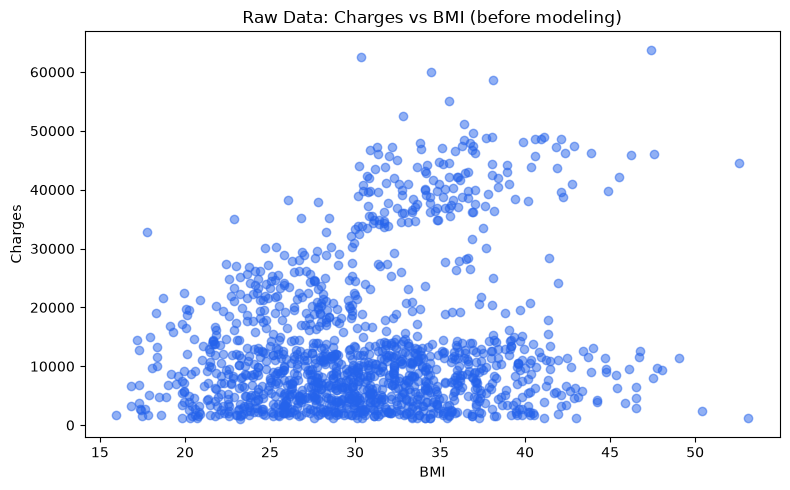

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(df["bmi"], df["charges"], color="#2563eb", alpha=0.5)
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("Raw Data: Charges vs BMI (before modeling)")
plt.tight_layout()
plt.savefig("../results/insurance_raw_data_plot.png", dpi=150)
plt.show()

## B) Building the Linear Regression model

In [7]:
X = df[["bmi"]]
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)

Train shape: (1069, 1)
Test shape:  (268, 1)


In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (m):     {slope:.2f}")
print(f"Intercept (b): {intercept:.2f}")

Slope (m):     345.17
Intercept (b): 2488.57


In [9]:
y_pred = model.predict(X_test)

pd.DataFrame({
    "bmi": X_test["bmi"].values,
    "Actual charges": y_test.values,
    "Predicted charges": y_pred,
}).round(2).head(10)

,bmi,Actual charges,Predicted charges
0,22.52,8688.86,10260.07
1,25.60,5708.87,11324.92
2,36.38,11436.74,15047.57
3,34.39,38746.36,14358.96
4,38.39,4463.21,15739.64
5,37.51,9304.70,15435.89
6,36.67,38511.63,15145.95
7,24.30,2150.47,10876.20
8,35.64,7345.73,14790.42
9,28.69,10264.44,12391.49


## C) Measuring model accuracy

In [10]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R^2:  {r2:.4f}")

MAE:  9891.12
MSE:  174251720.52
RMSE: 13200.44
R^2:  0.0517


### Before vs After: raw data vs the fitted regression line

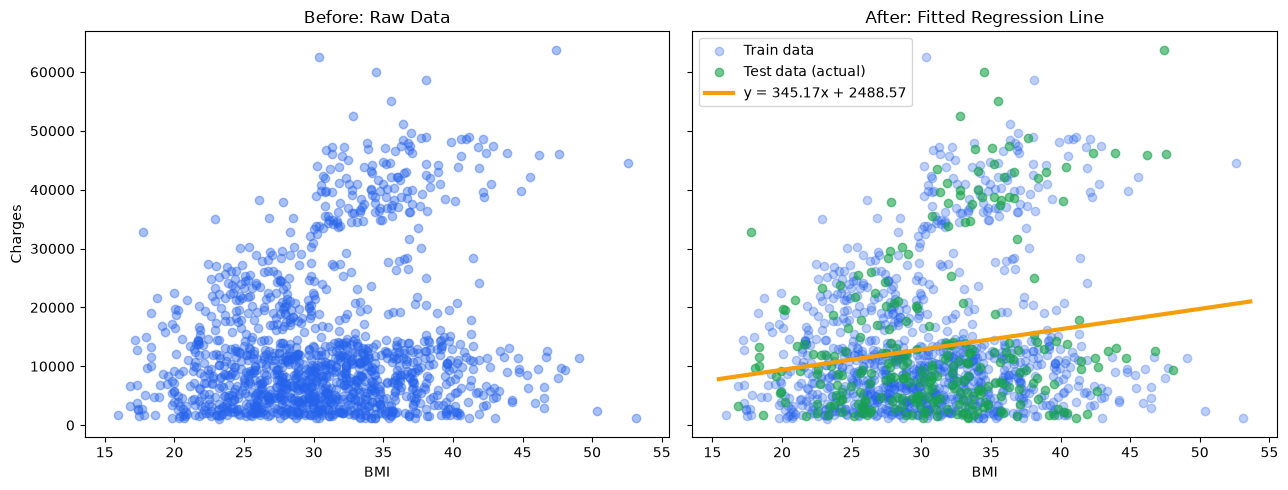

In [11]:
line_x = np.linspace(X["bmi"].min() - 0.5, X["bmi"].max() + 0.5, 50)
line_y = slope * line_x + intercept

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

axes[0].scatter(df["bmi"], df["charges"], color="#2563eb", alpha=0.4)
axes[0].set_title("Before: Raw Data")
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Charges")

axes[1].scatter(X_train, y_train, color="#2563eb", alpha=0.3, label="Train data")
axes[1].scatter(X_test, y_test, color="#16a34a", alpha=0.6, label="Test data (actual)")
axes[1].plot(line_x, line_y, color="#f59e0b", linewidth=3,
             label=f"y = {slope:.2f}x + {intercept:.2f}")
axes[1].set_title("After: Fitted Regression Line")
axes[1].set_xlabel("BMI")
axes[1].legend()

plt.tight_layout()
plt.savefig("../results/insurance_bmi_charges_plot.png", dpi=150)
plt.show()

## Outliers

`charges` is heavily right-skewed (max ≈ 63,770 vs mean ≈ 13,270), so there are clear outliers. We flag them with the IQR method and see how much they pull the line.

In [12]:
q1 = df["charges"].quantile(0.25)
q3 = df["charges"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

is_outlier = df["charges"] > upper_bound
print(f"IQR upper bound: {upper_bound:.2f}")
print(f"Outliers found:  {is_outlier.sum()} out of {len(df)} rows ({is_outlier.mean()*100:.1f}%)")

IQR upper bound: 34524.78
Outliers found:  139 out of 1337 rows (10.4%)


In [13]:
df_no_outliers = df[~is_outlier]

model_no_outliers = LinearRegression()
model_no_outliers.fit(df_no_outliers[["bmi"]], df_no_outliers["charges"])

slope_no_outliers = model_no_outliers.coef_[0]
intercept_no_outliers = model_no_outliers.intercept_

comparison = pd.DataFrame({
    "Fit": ["With outliers (full model)", "Without outliers"],
    "Slope": [slope, slope_no_outliers],
    "Intercept": [intercept, intercept_no_outliers],
})
comparison.round(2)

,Fit,Slope,Intercept
0,With outliers (full model),345.17,2488.57
1,Without outliers,-80.01,12342.70


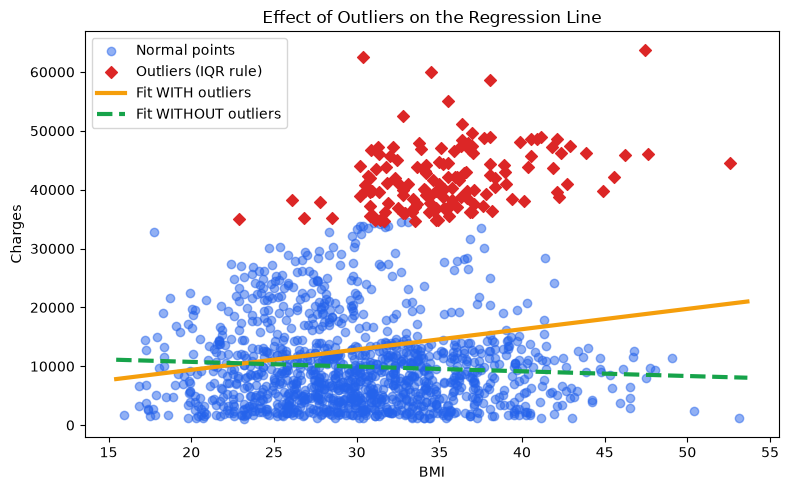

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df.loc[~is_outlier, "bmi"], df.loc[~is_outlier, "charges"],
            color="#2563eb", alpha=0.5, label="Normal points")
plt.scatter(df.loc[is_outlier, "bmi"], df.loc[is_outlier, "charges"],
            color="#dc2626", marker="D", label="Outliers (IQR rule)")

line_x = np.linspace(df["bmi"].min() - 0.5, df["bmi"].max() + 0.5, 50)
plt.plot(line_x, slope * line_x + intercept, color="#f59e0b", linewidth=3,
          label="Fit WITH outliers")
plt.plot(line_x, slope_no_outliers * line_x + intercept_no_outliers, color="#16a34a",
          linewidth=3, linestyle="--", label="Fit WITHOUT outliers")

plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("Effect of Outliers on the Regression Line")
plt.legend()
plt.tight_layout()
plt.savefig("../results/insurance_outliers_plot.png", dpi=150)
plt.show()